# 01 — Wrangle & Feature Engineer

**Purpose:** Load validated transactions, add time/classification features,
build monthly aggregates per category.

**Inputs:** `data/interim/transactions_validated.parquet`  
**Outputs:**
- `data/interim/transactions_featured.parquet`
- `data/interim/monthly_aggregates.parquet`

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display

from src.utils.logging_config import setup_notebook_logging
from src.analysis.feature_engineering import (
    engineer_features,
    build_monthly_aggregates,
    build_monthly_cashflow_split,
)
from src.storage.local_writer import LocalWriter

logger = setup_notebook_logging()
writer = LocalWriter(project_root="..")


In [2]:
# ── Load validated transactions ───────────────────────────────────────────────
df = writer.load_interim("transactions_validated")
print(f"Loaded {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

2026-03-30 13:05:50 | src.storage.local_writer       | INFO     | Loaded 16468 rows from C:\Users\mkkom\MMEXtend\data\interim\transactions_validated.parquet


Loaded 16468 rows × 14 columns
Memory: 2.9 MB


In [3]:
# ── Engineer features ─────────────────────────────────────────────────────────
df_featured = engineer_features(df)
print(f"\nNew columns added: {[c for c in df_featured.columns if c not in df.columns]}")
display(df_featured.head())

2026-03-30 13:05:50 | src.analysis.feature_engineering | INFO     | Features engineered: 16468 rows | 103 months | 4219 transfers | 0 uncategorised | 1257 pipe-split subcategories



New columns added: ['year', 'month', 'quarter', 'year_month', 'month_ordinal', 'is_transfer', 'is_uncategorised', 'subcategory_detail']


,transaction_id,date,account,to_account,payee,category,subcategory,amount,type,notes,...,currency,amount_pln,year,month,quarter,year_month,month_ordinal,is_transfer,is_uncategorised,subcategory_detail
0,1,2017-09-19,ING Direct,NaN,Kino,Leisure,Movies,-32.00,withdrawal,TO,...,PLN,-32.00,2017,9,3,2017-09,0,False,False,NaN
1,2,2017-09-19,ING Liquid,NaN,surplus.pl,Apparel,Jackets,-229.00,withdrawal,M-65 Hydro Fieldjacket,...,PLN,-229.00,2017,9,3,2017-09,0,False,False,NaN
2,3,2017-09-20,ING Direct,NaN,Biedronka,Alcohol,Wine,-11.99,withdrawal,,...,PLN,-11.99,2017,9,3,2017-09,0,False,False,NaN
3,4,2017-09-20,Portfel,NaN,S1,Income,Salary,136.00,deposit,,...,PLN,136.00,2017,9,3,2017-09,0,False,False,NaN
4,5,2017-09-20,ING Direct,NaN,Lewiatan,Alcohol,Beer,-2.49,withdrawal,,...,PLN,-2.49,2017,9,3,2017-09,0,False,False,NaN


In [4]:
# ── Transfers summary ─────────────────────────────────────────────────────────
n_transfers = df_featured["is_transfer"].sum()
print(f"Transfers (excluded from category analysis): {n_transfers} ({n_transfers/len(df_featured):.1%})")

Transfers (excluded from category analysis): 4219 (25.6%)


In [5]:
# ── Monthly aggregates ────────────────────────────────────────────────────────
monthly = build_monthly_aggregates(df_featured)
print(f"\nMonthly aggregates: {monthly.shape[0]} rows")
display(monthly.head(20))

2026-03-30 13:05:50 | src.analysis.feature_engineering | INFO     | Monthly aggregates: 1639 rows | 103 months | 31 categories



Monthly aggregates: 1639 rows


,year_month,category,total_amount,month_ordinal,mom_delta
0,2022-04,Accounting,-184.50,55,NaN
1,2023-04,Accounting,-124.00,67,60.50
2,2023-07,Accounting,-73.80,70,50.20
3,2023-11,Accounting,-282.90,74,-209.10
4,2023-12,Accounting,-12.30,75,270.60
5,2024-01,Accounting,-172.20,76,-159.90
6,2024-04,Accounting,-198.79,79,-26.59
7,2024-06,Accounting,-369.00,81,-170.21
8,2025-04,Accounting,-247.99,91,121.01
9,2025-07,Accounting,-369.00,94,-121.01


In [6]:
monthly['year_month'].unique()

<ArrowStringArray>
['2022-04', '2023-04', '2023-07', '2023-11', '2023-12', '2024-01', '2024-04',
 '2024-06', '2025-04', '2025-07',
 ...
 '2025-06', '2025-08', '2025-10', '2025-11', '2025-12', '2026-01', '2026-02',
 '2026-03', '2024-11', '2025-09']
Length: 103, dtype: str

In [7]:
# ── Top categories by total spend (absolute value) ────────────────────────────
top_cats = (
    monthly.groupby("category")["total_amount"]
    .sum()
    .abs()
    .sort_values(ascending=False)
    .head(15)
)
display(top_cats.rename("absolute_spend").to_frame())

,absolute_spend
category,
Income,1.558866e+06
Taxes,3.620157e+05
Bills,1.378548e+05
Food,1.187992e+05
Tabletop,5.979433e+04
Wedding,4.363871e+04
Electronics,4.288883e+04
Leisure,3.629372e+04
Gifts,3.370134e+04


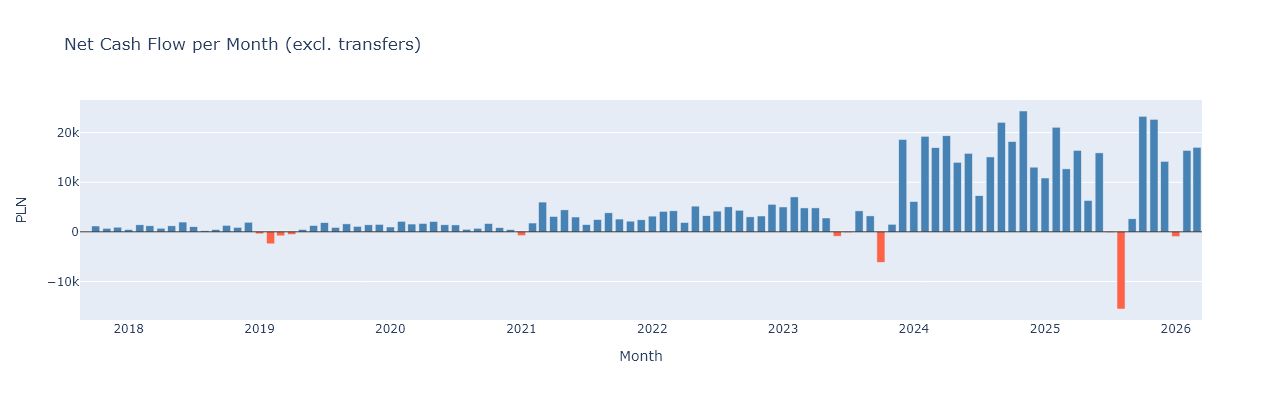

In [8]:
# ── Net cash flow per month (income - expenses, excluding transfers) ───────────
net_monthly = (
    monthly.groupby("year_month")["total_amount"]
    .sum()
    .reset_index()
    .rename(columns={"total_amount": "net_cashflow"})
)

colors = ["steelblue" if v >= 0 else "tomato" for v in net_monthly["net_cashflow"]]
fig = go.Figure(go.Bar(
    x=net_monthly["year_month"],
    y=net_monthly["net_cashflow"],
    marker_color=colors,
))
fig.add_hline(y=0, line_color="black", line_width=0.8)
fig.update_layout(
    title="Net Cash Flow per Month (excl. transfers)",
    xaxis_title="Month",
    yaxis_title="PLN",
    height=400,
)
fig.show()

## Deposits vs Withdrawals split

Break the net cash flow into its two components and derive disposable income per month.
`type` column values: `deposit` (income, positive), `withdrawal` (expense, sign-flipped to positive),
`transfer` (excluded).
Disposable income = deposits − withdrawals. Savings rate = disposable income / deposits.

In [9]:
# ── Deposits vs Withdrawals monthly split ─────────────────────────────────────
cashflow_split = build_monthly_cashflow_split(df_featured)
print(f"Months: {len(cashflow_split)}")
display(cashflow_split.round(0))

2026-03-30 13:05:51 | src.analysis.feature_engineering | INFO     | Cashflow split: 103 months | avg deposits=15495 | avg withdrawals=10488 | avg savings_rate=25.3%


Months: 103


,year_month,month_ordinal,deposits,withdrawals,disposable_income,savings_rate
0,2017-09,0,712.0,729.0,-17.0,-0.0
1,2017-10,1,2506.0,1330.0,1176.0,0.0
2,2017-11,2,2269.0,1572.0,697.0,0.0
3,2017-12,3,2622.0,1686.0,936.0,0.0
4,2018-01,4,2376.0,1927.0,449.0,0.0
...,...,...,...,...,...,...
98,2025-11,98,48409.0,25740.0,22669.0,0.0
99,2025-12,99,37412.0,23214.0,14198.0,0.0
100,2026-01,100,18418.0,19364.0,-946.0,-0.0
101,2026-02,101,40236.0,23830.0,16406.0,0.0


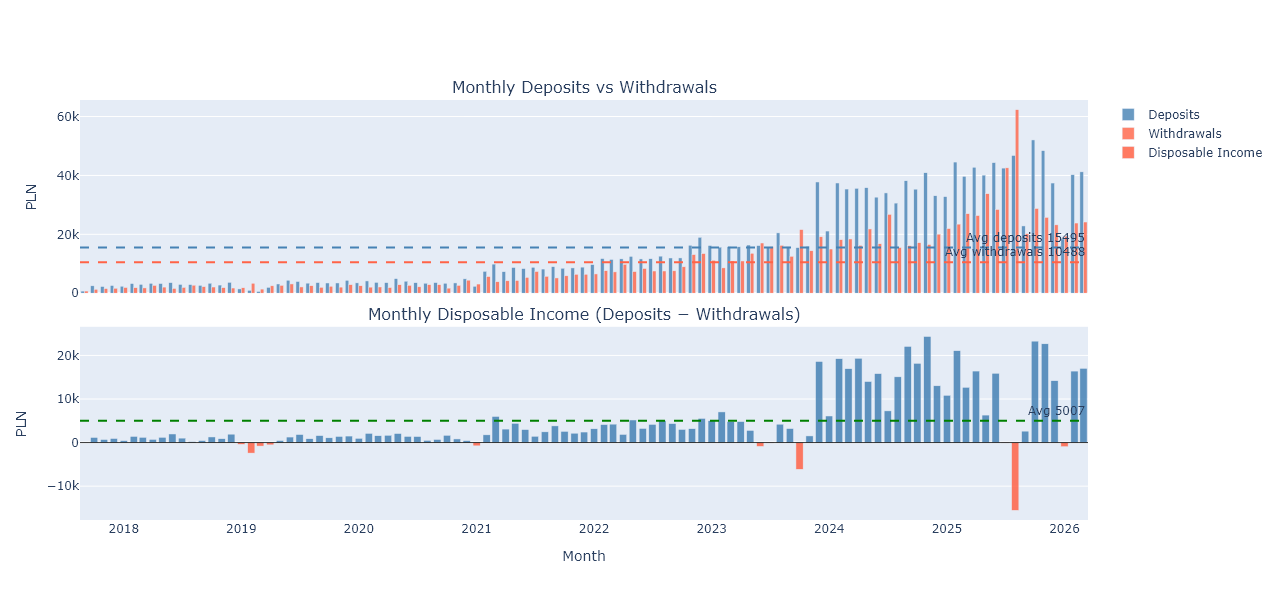


Average savings rate: 25.3%
Months with negative disposable income: 12 / 103


In [10]:
# ── Visualise: deposits / withdrawals / disposable income ─────────────────────
x = cashflow_split["year_month"]
avg_dep = cashflow_split["deposits"].mean()
avg_wdw = cashflow_split["withdrawals"].mean()
avg_di = cashflow_split["disposable_income"].mean()
di_colors = ["steelblue" if v >= 0 else "tomato" for v in cashflow_split["disposable_income"]]

fig = make_subplots(
    rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.08,
    subplot_titles=("Monthly Deposits vs Withdrawals",
                    "Monthly Disposable Income (Deposits − Withdrawals)"),
)

fig.add_trace(go.Bar(x=x, y=cashflow_split["deposits"], name="Deposits",
                     marker_color="steelblue", opacity=0.8), row=1, col=1)
fig.add_trace(go.Bar(x=x, y=cashflow_split["withdrawals"], name="Withdrawals",
                     marker_color="tomato", opacity=0.8), row=1, col=1)
fig.add_hline(y=avg_dep, line_color="steelblue", line_dash="dash",
              annotation_text=f"Avg deposits {avg_dep:.0f}", row=1, col=1)
fig.add_hline(y=avg_wdw, line_color="tomato", line_dash="dash",
              annotation_text=f"Avg withdrawals {avg_wdw:.0f}", row=1, col=1)

fig.add_trace(go.Bar(x=x, y=cashflow_split["disposable_income"],
                     marker_color=di_colors, opacity=0.85, name="Disposable Income"),
              row=2, col=1)
fig.add_hline(y=0, line_color="black", line_width=0.8, row=2, col=1)
fig.add_hline(y=avg_di, line_color="green", line_dash="dash",
              annotation_text=f"Avg {avg_di:.0f}", row=2, col=1)

fig.update_yaxes(title_text="PLN", row=1, col=1)
fig.update_yaxes(title_text="PLN", row=2, col=1)
fig.update_xaxes(title_text="Month", row=2, col=1)
fig.update_layout(height=600, barmode="group")
fig.show()

avg_sr = cashflow_split["savings_rate"].mean()
print(f"\nAverage savings rate: {avg_sr:.1%}")
print(f"Months with negative disposable income: "
      f"{(cashflow_split['disposable_income'] < 0).sum()} / {len(cashflow_split)}")

In [11]:
# ── Save outputs ──────────────────────────────────────────────────────────────
writer.save_interim(df_featured, "transactions_featured")
writer.save_interim(monthly, "monthly_aggregates")
writer.save_interim(cashflow_split, "monthly_cashflow_split")
print("Saved:")
print("  data/interim/transactions_featured.parquet")
print("  data/interim/monthly_aggregates.parquet")
print("  data/interim/monthly_cashflow_split.parquet")


2026-03-30 13:05:51 | src.storage.local_writer       | INFO     | Wrote 16468 rows to C:\Users\mkkom\MMEXtend\data\interim\transactions_featured.parquet
2026-03-30 13:05:51 | src.storage.local_writer       | INFO     | Wrote 1639 rows to C:\Users\mkkom\MMEXtend\data\interim\monthly_aggregates.parquet
2026-03-30 13:05:51 | src.storage.local_writer       | INFO     | Wrote 103 rows to C:\Users\mkkom\MMEXtend\data\interim\monthly_cashflow_split.parquet


Saved:
  data/interim/transactions_featured.parquet
  data/interim/monthly_aggregates.parquet
  data/interim/monthly_cashflow_split.parquet
